In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import wandb

# utils

In [17]:
def get_color_cycle(algorithms):
  """
  Creates a circular buffer of colors for plotting multiple algorithms.

  Args:
    algorithms: A list of algorithm names.

  Returns:
    A dictionary mapping each algorithm to a unique color.
  """
  colors = itertools.cycle(plt.colormaps.get_cmap('tab10').colors)  # You can choose a different colormap
  color_map = {}
  for algorithm in algorithms:
    color_map[algorithm] = next(colors)
  return color_map


# Create a custom handler for vertical lines in legend
class VerticalLineHandler:
    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        width = handlebox.width
        height = handlebox.height
        # Create a vertical line in the center of the box
        line = plt.Line2D([x0 + width/2, x0 + width/2],
                         [y0, y0 + height],
                         color=orig_handle.get_color(),
                         linestyle=orig_handle.get_linestyle())
        handlebox.add_artist(line)
        return line


# formatting stuff:
title_font_dict = {'weight': 'bold', 'size': 30}
axis_font_dict = {'weight': 'bold', 'size': 18}
legend_font_dict = {'weight': 'bold', 'size': 16}


# setup

In [27]:
api = wandb.Api()

In [28]:
runs = api.runs("jfcevallos/TIGER2.0")

In [29]:
default_run_id = "kp5mp4f9"

for run in runs:
    if run.id == default_run_id:
        print(run.name, run.id)
        default_run_name = run.name
        default_run = run
        # print('scanning run history:')
        # default_run_history = list(run.scan_history(keys=None))
        # print('creating dataframe:')
        # default_run_history = pd.DataFrame(history_rows)
        default_run_history = run.history(samples=20000)
        default_run_history.set_index("_runtime", inplace=True)
        break

DDQN kp5mp4f9


# ASAP Architectures

In [37]:
asap_runs = {}
for run in runs:
    if run.group == "arch_agency":
        print(run.name, run.id)
        asap_runs[run.name] = {
            "id": run.id}
        # print('scanning run history:')
        # history_rows = list(run.scan_history(keys=None))
        # print('creating dataframe:')
        # asap_runs[run.name]["history"] = pd.DataFrame(history_rows)
        asap_runs[run.name]["history"] = run.history(samples=20000)
        asap_runs[run.name]["history"].set_index("_runtime", inplace=True)


asap_runs["agency_optim"]["display_name"] = "Optimised Models"
asap_runs["agency_simple_krloss"]["display_name"] = "Simple_KRLoss"
asap_runs["agency_dotprod_kr"]["display_name"] = "DotProd_KR"
asap_runs["agency_dotprod_kr_simplekrloss"]["display_name"] = "DotProd_KR_SimpleKRLoss"

asap_runs[default_run_name] = {
    "id": default_run_id,
    "history": default_run_history,
    "display_name": "Default"
}

agency_simple_krloss oa9to1ej
agency_optim 3ctewnbd
agency_dotprod_kr ca2z4r0q
agency_dotprod_kr_simplekrloss u273eepm


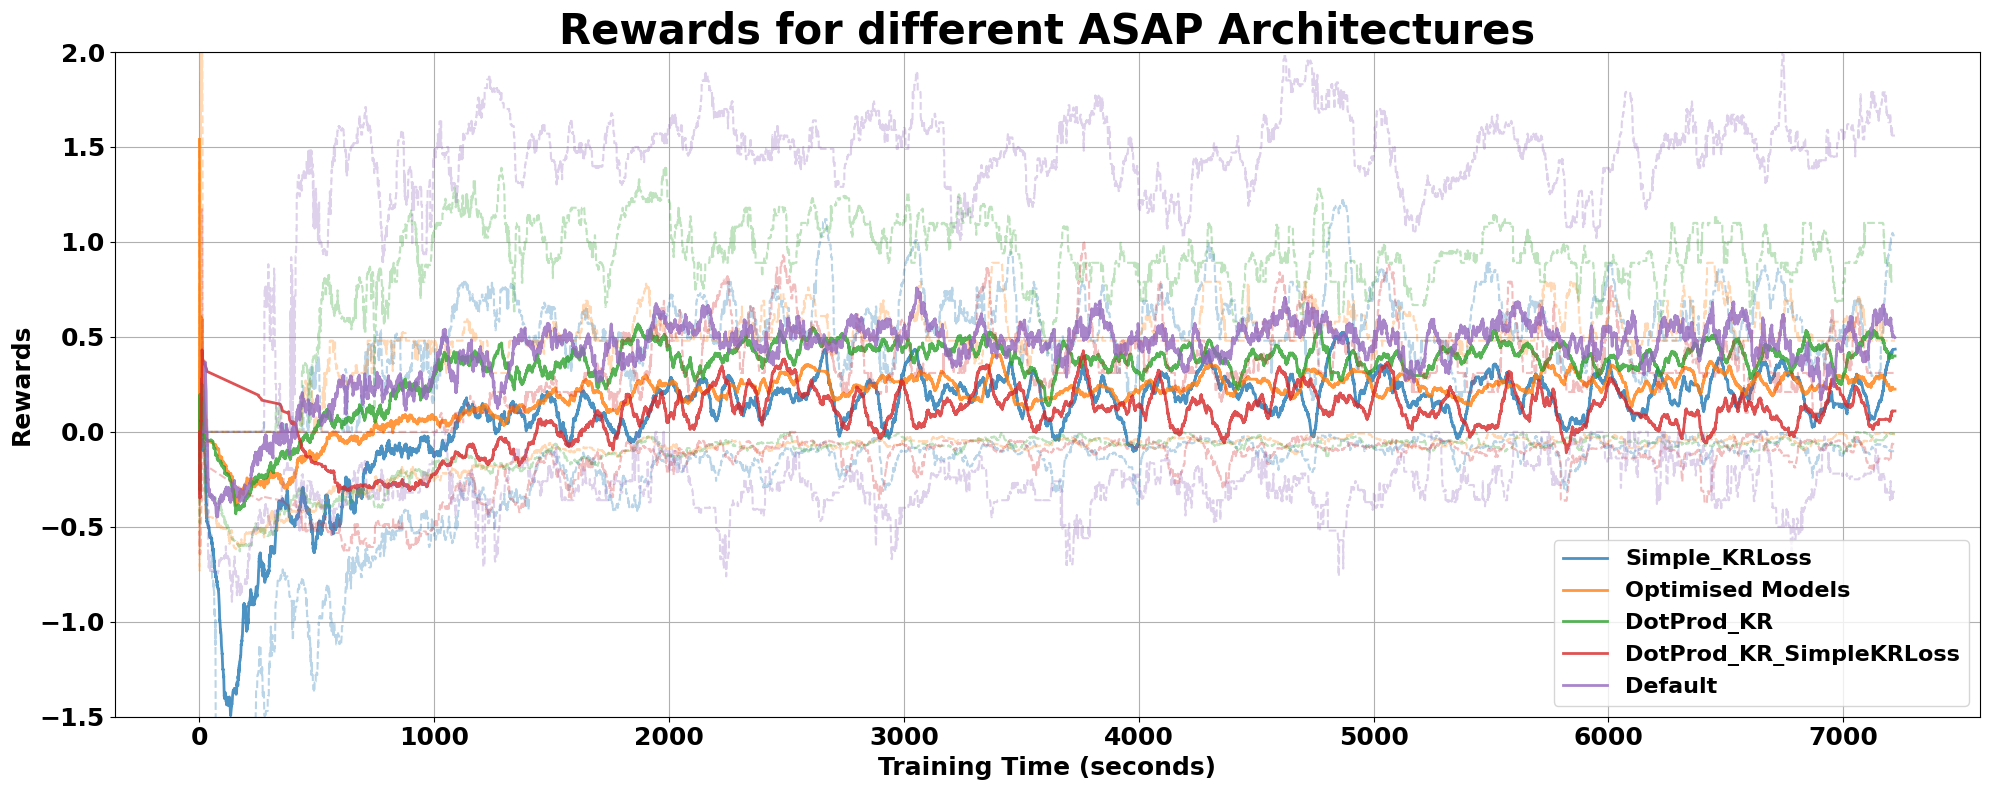

In [40]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 1, 1)

# Adjustable smoothing parameters
SMOOTHING_ALPHA = 0.8 # Transparency for the running average line
ROLLING_WINDOW_SIZE = 150 # Number of samples for rolling calculations

algorithms = [run_dict["display_name"] if "display_name" in run_dict else run_name for run_name, run_dict in asap_runs.items()]
color_map = get_color_cycle(algorithms)

for run_name, run_dict in asap_runs.items():
    display_name = run_dict.get("display_name", run_name)
    history_df = run_dict["history"].copy() # Work on a copy to avoid modifying original data

    if "AGENT/generic_reward" in history_df.columns and not history_df["AGENT/generic_reward"].empty:
        reward_series = history_df["AGENT/generic_reward"]

        # Calculate running average (instead of EMA)
        running_avg_series = reward_series.rolling(window=ROLLING_WINDOW_SIZE, min_periods=1).mean()

        # Calculate rolling 1st and 3rd quantiles from the original reward series
        q1_series = reward_series.rolling(window=ROLLING_WINDOW_SIZE, min_periods=1).quantile(0.25)
        q3_series = reward_series.rolling(window=ROLLING_WINDOW_SIZE, min_periods=1).quantile(0.75)

        # Plot Running Average line with specified alpha
        plt.plot(running_avg_series.index, running_avg_series,
                 # label=f'{display_name} (Running Avg, window={ROLLING_WINDOW_SIZE})',
                 label=f'{display_name}',
                 color=color_map[display_name],
                 linewidth=2,
                 alpha=SMOOTHING_ALPHA)

        # Plot 1st and 3rd quantiles
        plt.plot(q1_series.index, q1_series,
                 #label=f'{display_name} (1st Q)',
                 color=color_map[display_name],
                 linestyle='--',
                 alpha=0.3)
        plt.plot(q3_series.index, q3_series,
                 #label=f'{display_name} (3rd Q)',
                 color=color_map[display_name],
                 linestyle='--',
                 alpha=0.3)

# Make axis numbers big and bold
plt.tick_params(axis='x', labelsize=axis_font_dict['size'])
plt.tick_params(axis='y', labelsize=axis_font_dict['size'])

# Make tick labels bold
for tick in plt.gca().get_xticklabels():
    tick.set_fontweight('bold')
for tick in plt.gca().get_yticklabels():
    tick.set_fontweight('bold')

plt.title('Rewards for different ASAP Architectures', **title_font_dict)
plt.xlabel('Training Time (seconds)', **axis_font_dict)
plt.ylabel('Rewards', **axis_font_dict)
plt.ylim(-1.5, 2) # Set y-axis limits
plt.legend(prop=legend_font_dict)
plt.grid(True)
plt.tight_layout()
plt.show()